# Exercise 2: Distributed Sales Data Analysis using PySpark

**Objectives:**
- Load the Retail Transactions dataset
- Perform distributed analysis with Spark
- Apply cleaning, grouping and aggregation
- Visualize aggregated results

**Tasks:**
1. Load dataset
2. Clean missing / invalid values
3. Compute total sales, top countries/products, average sales
4. Visualize results
5. Explain how Spark distributes processing

**Using Pyspark**

## 0. Setup & Load Dataset
Initialize Spark and load `data/Retail_Transactions_Dataset.csv`. The notebook detects the available column names and adapts calculations accordingly.

In [33]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder \
    .appName("Sales Analysis Project") \
    .getOrCreate()

data_path = "../data/Retail_Transactions_Dataset.csv"

# Load dataset with header and inferred schema
sales_df = spark.read.csv(data_path, header=True, inferSchema=True)
print("Schema after initial load:")
sales_df.printSchema()
print(f"Total records: {sales_df.count()}")

Schema after initial load:
root
 |-- Transaction_ID: integer (nullable = true)
 |-- Date: timestamp (nullable = true)
 |-- Customer_Name: string (nullable = true)
 |-- Product: string (nullable = true)
 |-- Total_Items: integer (nullable = true)
 |-- Total_Cost: double (nullable = true)
 |-- Payment_Method: string (nullable = true)
 |-- City: string (nullable = true)
 |-- Store_Type: string (nullable = true)
 |-- Discount_Applied: boolean (nullable = true)
 |-- Customer_Category: string (nullable = true)
 |-- Season: string (nullable = true)
 |-- Promotion: string (nullable = true)

Total records: 1000000


## Task 1: Inspect and normalize column names
We'll detect which columns are present and create a small mapping to use later in the notebook.

In [34]:
cols = sales_df.columns
print("Columns in dataset:", cols)

def find_col(*names):
    for name in names:
        for c in cols:
            if c.lower() == name.lower():
                return c
    return None

# Common candidates (adjust as needed)
transaction_col = find_col('transaction_id', 'Transaction_ID', 'InvoiceNo')
product_col = find_col('product_id', 'Product', 'StockCode')
description_col = find_col('description', 'Description')
quantity_col = find_col('quantity', 'Total_Items')
unit_price_col = find_col('unit_price', 'UnitPrice')
total_cost_col = find_col('total_cost', 'Total_Cost', 'TotalPrice', 'Total_Price')
country_col = find_col('country', 'Country', 'City')
customer_col = find_col('customer_id', 'CustomerID', 'Customer_Name')

print('Detected mapping:' , {
    'transaction_col': transaction_col,
    'product_col': product_col,
    'description_col': description_col,
    'quantity_col': quantity_col,
    'unit_price_col': unit_price_col,
    'total_cost_col': total_cost_col,
    'country_col': country_col,
    'customer_col': customer_col
})

Columns in dataset: ['Transaction_ID', 'Date', 'Customer_Name', 'Product', 'Total_Items', 'Total_Cost', 'Payment_Method', 'City', 'Store_Type', 'Discount_Applied', 'Customer_Category', 'Season', 'Promotion']
Detected mapping: {'transaction_col': 'Transaction_ID', 'product_col': 'Product', 'description_col': None, 'quantity_col': 'Total_Items', 'unit_price_col': None, 'total_cost_col': 'Total_Cost', 'country_col': 'City', 'customer_col': 'Customer_Name'}


## Task 2: Clean missing / invalid values
Drop rows missing the numeric fields we need and remove non-positive quantities (returns).

In [35]:
# Start with a copy reference
clean_sales_df = sales_df

# Drop rows missing total-cost-equivalent or quantity/unit-price pair
if total_cost_col is not None:
    clean_sales_df = clean_sales_df.dropna(subset=[total_cost_col])
else:
    clean_sales_df = clean_sales_df.dropna(subset=[c for c in (quantity_col, unit_price_col) if c is not None])

# If we have a quantity column, ensure it's numeric and > 0
from pyspark.sql.functions import col
if quantity_col is not None:
    clean_sales_df = clean_sales_df.withColumn(quantity_col, col(quantity_col).cast('double')).filter(col(quantity_col) > 0)

# Ensure unit price is numeric when present
if unit_price_col is not None:
    clean_sales_df = clean_sales_df.withColumn(unit_price_col, col(unit_price_col).cast('double'))

print(f"Total records after cleaning: {clean_sales_df.count()}")

Total records after cleaning: 1000000


## Task 3: Compute Aggregations
Compute total sales, top countries, top products and average per-transaction sales using available columns.

In [36]:
# Using PySpark
from pyspark.sql.functions import col, sum as spark_sum, avg, desc

# Compute total_price from the best available columns
if total_cost_col is not None:
    sales_with_total = clean_sales_df.withColumn('total_price', col(total_cost_col).cast('double'))
elif quantity_col is not None and unit_price_col is not None:
    sales_with_total = clean_sales_df.withColumn('total_price', col(quantity_col).cast('double') * col(unit_price_col).cast('double'))
else:
    raise ValueError('Cannot compute total_price: dataset lacks Total_Cost and Quantity+UnitPrice columns')

# 1. Total Sales overall
total_sales_value = sales_with_total.select(spark_sum('total_price')).collect()[0][0]
print(f"Total Sales: ${total_sales_value:,.2f}\n")

# 2. Top countries by sales (if we have a country-like column)
if country_col is not None:
    country_sales = sales_with_total.groupBy(country_col) \
        .agg(spark_sum('total_price').alias('country_total_sales')) \
        .orderBy(desc('country_total_sales'))
    print("Top countries by sales:")
    country_sales.show(10)
else:
    country_sales = None

# 3. Top products by sales (group by product id and/or description)
group_cols = []
if product_col is not None: group_cols.append(product_col)
if description_col is not None and description_col not in group_cols: group_cols.append(description_col)
if group_cols:
    product_sales = sales_with_total.groupBy(*group_cols) \
        .agg(spark_sum('total_price').alias('product_total_sales')) \
        .orderBy(desc('product_total_sales'))
    print("Top products by sales:")
    product_sales.show(10)
else:
    product_sales = None

# 4. Average sales per transaction/invoice (if transaction id exists)
if transaction_col is not None:
    invoice_totals = sales_with_total.groupBy(transaction_col).agg(spark_sum('total_price').alias('invoice_total'))
    avg_sales_value = invoice_totals.select(avg('invoice_total')).collect()[0][0]
    print(f"Average Sales per Transaction: ${avg_sales_value:,.2f}")
else:
    print('Transaction identifier not found; skipping average-per-transaction')

Total Sales: $52,455,220.40

Top countries by sales:
+-------------+-------------------+
|         City|country_total_sales|
+-------------+-------------------+
|       Dallas|  5277111.529999999|
|       Boston|  5263307.959999999|
|      Chicago|  5263187.450000004|
|     New York|         5252469.92|
|      Houston| 5247054.7799999975|
|San Francisco|  5241099.859999998|
|        Miami|  5240498.440000003|
|      Seattle|  5235365.429999995|
|  Los Angeles|         5232393.19|
|      Atlanta|  5202731.839999999|
+-------------+-------------------+

Top products by sales:
+--------------+-------------------+
|       Product|product_total_sales|
+--------------+-------------------+
|['Toothpaste']| 253689.00999999998|
|     ['Honey']| 135409.84999999998|
| ['Deodorant']| 133082.76999999996|
|     ['Pasta']| 131765.68999999997|
|      ['Eggs']|          131565.71|
|   ['Vinegar']| 131538.38999999998|
|      ['Soap']|          131183.28|
|    ['Razors']| 130956.56999999999|
|    ['Salmo

## Task 4: Visualize Results
Collect small aggregated tables to Pandas and plot with Matplotlib/Seaborn.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27212\903928334.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country_total_sales', y=x_col, data=country_pd, palette='Blues_d')


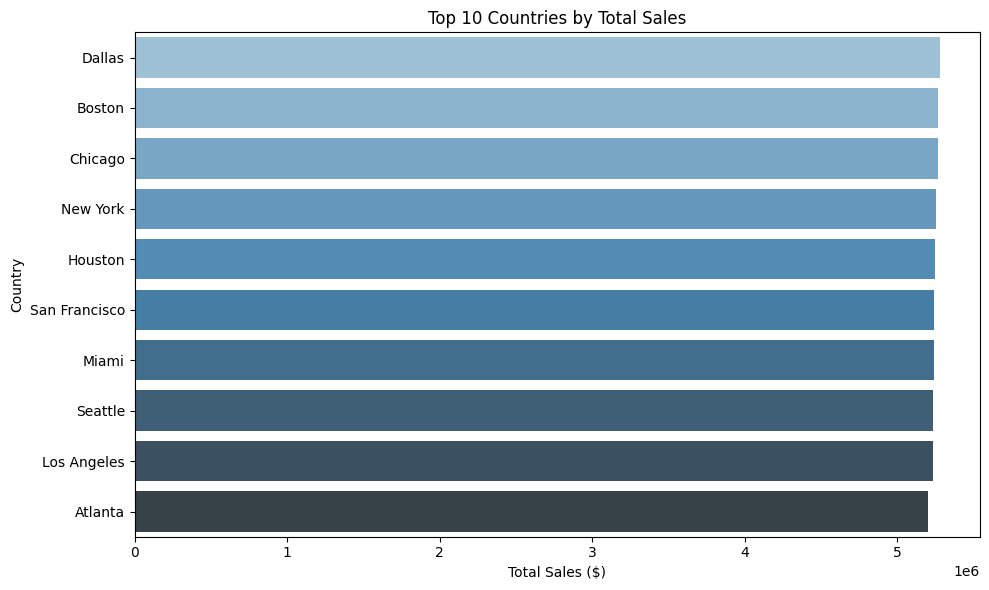

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27212\903928334.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_total_sales', y=label_col, data=prod_pd, palette='Greens_d')


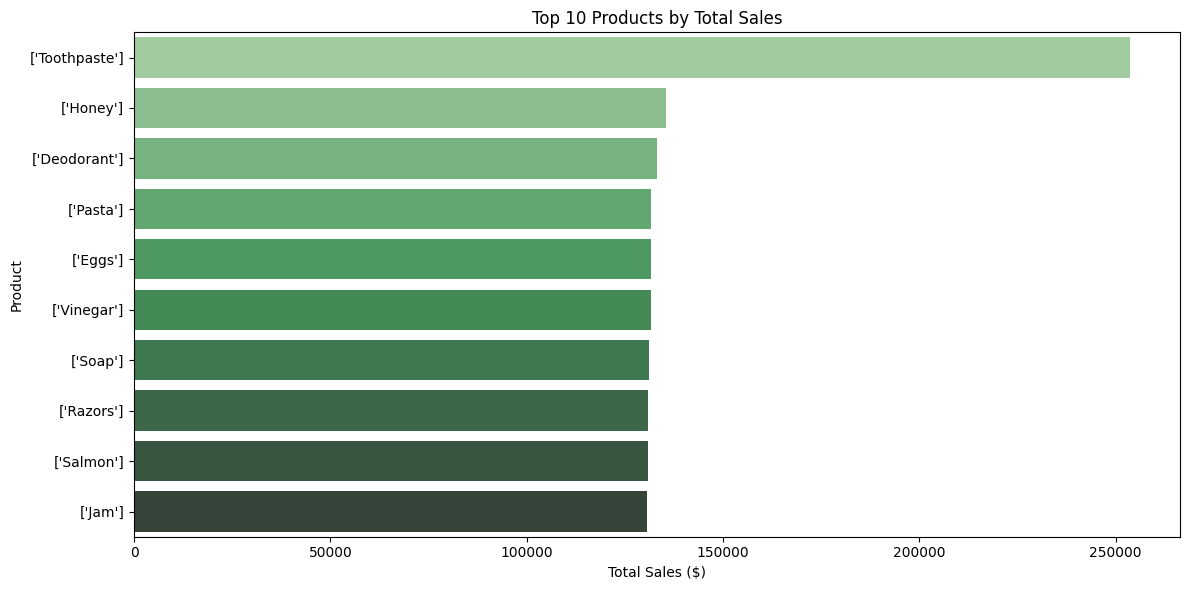

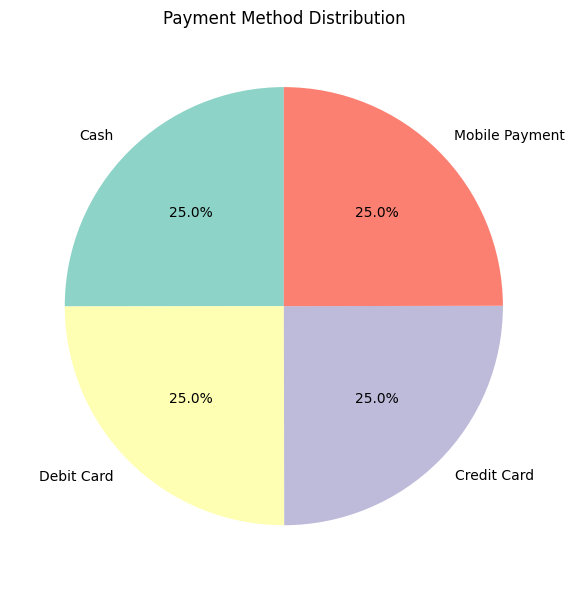

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27212\903928334.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season', y='Revenue', data=season_revenue_pd, palette='coolwarm')


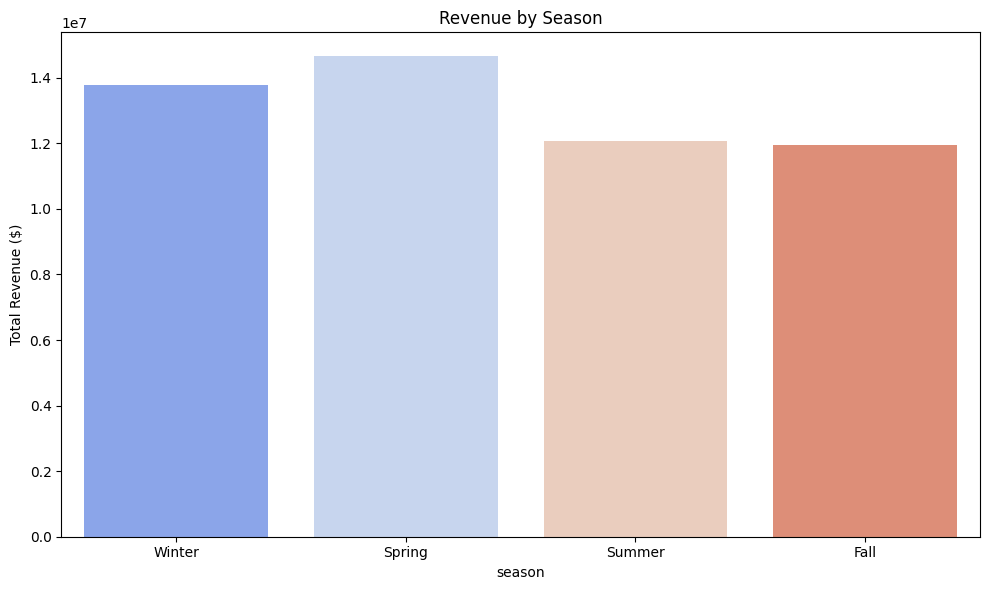

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot top countries if available
if 'country_sales' in globals() and country_sales is not None:
    country_pd = country_sales.limit(10).toPandas()
    x_col = country_pd.columns[0]
    plt.figure(figsize=(10,6))
    sns.barplot(x='country_total_sales', y=x_col, data=country_pd, palette='Blues_d')
    plt.title('Top 10 Countries by Total Sales')
    plt.xlabel('Total Sales ($)')
    plt.ylabel('Country')
    plt.tight_layout()
    plt.show()
else:
    print('No country sales to plot')

# Plot top products if available
if 'product_sales' in globals() and product_sales is not None:
    prod_pd = product_sales.limit(10).toPandas()
    # choose a label column (prefer description)
    label_col = None
    for c in prod_pd.columns:
        if c.lower() in ('description', 'product', 'product_id'):
            label_col = c
            break
    if label_col is None: label_col = prod_pd.columns[0]
    plt.figure(figsize=(12,6))
    sns.barplot(x='product_total_sales', y=label_col, data=prod_pd, palette='Greens_d')
    plt.title('Top 10 Products by Total Sales')
    plt.xlabel('Total Sales ($)')
    plt.ylabel('Product')
    plt.tight_layout()
    plt.show()
else:
    print('No product sales to plot')

# Payment Distribution
payment_col = find_col('payment_method', 'Payment_Method', 'PaymentType', 'Payment')

if payment_col is not None:
    payment_dist_spark = clean_sales_df.groupBy(payment_col).count().orderBy(desc('count'))
    payment_dist_pd = payment_dist_spark.toPandas()
    
    plt.figure(figsize=(10, 6))
    colors = plt.cm.Set3(range(len(payment_dist_pd)))
    plt.pie(payment_dist_pd['count'].values, labels=payment_dist_pd[payment_col].values, 
            autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title('Payment Method Distribution')
    plt.tight_layout()
    plt.show()
else:
    print('Payment method column not found; cannot plot payment distribution')

# Seasonal Revenue
date_col = find_col('date', 'Date', 'Transaction_Date', 'InvoiceDate')

if date_col is not None:
    from pyspark.sql.functions import to_date, month, when
    
    # Parse date and extract month
    sales_with_date = sales_with_total.withColumn('date', to_date(col(date_col)))
    sales_with_date = sales_with_date.withColumn('month', month(col('date')))
    
    # Map months to seasons
    season_col = when((col('month').isin(12, 1, 2)), 'Winter') \
                 .when((col('month').isin(3, 4, 5)), 'Spring') \
                 .when((col('month').isin(6, 7, 8)), 'Summer') \
                 .otherwise('Fall')
    
    sales_with_date = sales_with_date.withColumn('season', season_col)
    
    # Revenue by season
    season_revenue_spark = sales_with_date.groupBy('season') \
        .agg(spark_sum('total_price').alias('Revenue')) \
        .orderBy(desc('Revenue'))
    
    season_revenue_pd = season_revenue_spark.toPandas()
    
    # Reorder by season (not by revenue)
    season_order = ['Winter', 'Spring', 'Summer', 'Fall']
    season_revenue_pd['season'] = pd.Categorical(season_revenue_pd['season'], 
                                                   categories=season_order, ordered=True)
    season_revenue_pd = season_revenue_pd.sort_values('season')
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='season', y='Revenue', data=season_revenue_pd, palette='coolwarm')
    plt.title('Revenue by Season')
    plt.ylabel('Total Revenue ($)')
    plt.tight_layout()
    plt.show()
else:
    print('Date column not found; cannot compute seasonal revenue')


**Use Pandas**

## 0. Setup & Load Dataset
Initialize Pandas and load `data/Retail_Transactions_Dataset.csv`. The notebook detects the available column names and adapts calculations accordingly.

In [42]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np  

data_path = "../data/Retail_Transactions_Dataset.csv"
sales = pd.read_csv(data_path)

print("Schema after initial load:")
print(sales.dtypes)
print(f"Total records: {len(sales)}\n")


Schema after initial load:
Transaction_ID         int64
Date                     str
Customer_Name            str
Product                  str
Total_Items            int64
Total_Cost           float64
Payment_Method           str
City                     str
Store_Type               str
Discount_Applied        bool
Customer_Category        str
Season                   str
Promotion                str
dtype: object
Total records: 1000000



## Task 1: Inspect and normalize column names
We'll detect which columns are present and create a small mapping to use later in the notebook.

In [43]:
cols = sales.columns.tolist()
print("Columns in dataset:", cols)

def find_col(*names):
    for name in names:
        for c in cols:
            if c.lower() == name.lower():
                return c
    return None

# Common candidates
transaction_col = find_col('transaction_id', 'Transaction_ID', 'InvoiceNo')
product_col = find_col('product_id', 'Product', 'StockCode')
description_col = find_col('description', 'Description')
quantity_col = find_col('quantity', 'Total_Items')
unit_price_col = find_col('unit_price', 'UnitPrice')
total_cost_col = find_col('total_cost', 'Total_Cost', 'TotalPrice', 'Total_Price')
country_col = find_col('country', 'Country', 'City')
customer_col = find_col('customer_id', 'CustomerID', 'Customer_Name')

print('Detected mapping:', {
    'transaction_col': transaction_col,
    'product_col': product_col,
    'description_col': description_col,
    'quantity_col': quantity_col,
    'unit_price_col': unit_price_col,
    'total_cost_col': total_cost_col,
    'country_col': country_col,
    'customer_col': customer_col
})

Columns in dataset: ['Transaction_ID', 'Date', 'Customer_Name', 'Product', 'Total_Items', 'Total_Cost', 'Payment_Method', 'City', 'Store_Type', 'Discount_Applied', 'Customer_Category', 'Season', 'Promotion']
Detected mapping: {'transaction_col': 'Transaction_ID', 'product_col': 'Product', 'description_col': None, 'quantity_col': 'Total_Items', 'unit_price_col': None, 'total_cost_col': 'Total_Cost', 'country_col': 'City', 'customer_col': 'Customer_Name'}


## Task 2: Clean missing / invalid values
Drop rows missing the numeric fields we need and remove non-positive quantities (returns).

In [44]:
clean_sales = sales.copy()

# Drop rows with missing total-cost or quantity/unit-price
if total_cost_col is not None:
    clean_sales = clean_sales.dropna(subset=[total_cost_col])
else:
    cols_to_check = [c for c in (quantity_col, unit_price_col) if c is not None]
    clean_sales = clean_sales.dropna(subset=cols_to_check)

# Ensure quantity is numeric and > 0
if quantity_col is not None:
    clean_sales[quantity_col] = pd.to_numeric(clean_sales[quantity_col], errors='coerce')
    clean_sales = clean_sales[clean_sales[quantity_col] > 0]

# Ensure unit price is numeric
if unit_price_col is not None:
    clean_sales[unit_price_col] = pd.to_numeric(clean_sales[unit_price_col], errors='coerce')

print(f"Total records after cleaning: {len(clean_sales)}\n")


Total records after cleaning: 1000000



## Task 3: Compute Aggregations
Compute total sales, top countries, top products and average per-transaction sales using available columns.

In [45]:
# Compute total_price from available columns
if total_cost_col is not None:
    clean_sales['total_price'] = pd.to_numeric(clean_sales[total_cost_col], errors='coerce')
elif quantity_col is not None and unit_price_col is not None:
    clean_sales['total_price'] = pd.to_numeric(clean_sales[quantity_col], errors='coerce') * \
                                  pd.to_numeric(clean_sales[unit_price_col], errors='coerce')
else:
    raise ValueError('Cannot compute total_price: dataset lacks Total_Cost and Quantity+UnitPrice columns')

# 1. Total Sales overall
total_sales_value = clean_sales['total_price'].sum()
print(f"Total Sales: ${total_sales_value:,.2f}\n")

# 2. Top countries by sales
if country_col is not None:
    country_sales = clean_sales.groupby(country_col)['total_price'].sum().reset_index()
    country_sales.columns = [country_col, 'country_total_sales']
    country_sales = country_sales.sort_values('country_total_sales', ascending=False)
    print("Top countries by sales:")
    print(country_sales.head(10))
    print()
else:
    country_sales = None
# 3. Top products by sales
group_cols = []
if product_col is not None: group_cols.append(product_col)
if description_col is not None and description_col not in group_cols: group_cols.append(description_col)

if group_cols:
    product_sales = clean_sales.groupby(group_cols)['total_price'].sum().reset_index()
    product_sales.columns = group_cols + ['product_total_sales']
    product_sales = product_sales.sort_values('product_total_sales', ascending=False)
    print("Top products by sales:")
    print(product_sales.head(10))
    print()
else:
    product_sales = None

# 4. Average sales per transaction/invoice
if transaction_col is not None:
    invoice_totals = clean_sales.groupby(transaction_col)['total_price'].sum()
    avg_sales_value = invoice_totals.mean()
    print(f"Average Sales per Transaction: ${avg_sales_value:,.2f}")
else:
    print('Transaction identifier not found; skipping average-per-transaction')

Total Sales: $52,455,220.40

Top countries by sales:
            City  country_total_sales
3         Dallas           5277111.53
1         Boston           5263307.96
2        Chicago           5263187.45
7       New York           5252469.92
4        Houston           5247054.78
8  San Francisco           5241099.86
6          Miami           5240498.44
9        Seattle           5235365.43
5    Los Angeles           5232393.19
0        Atlanta           5202731.84

Top products by sales:
               Product  product_total_sales
522814  ['Toothpaste']            253689.01
223288       ['Honey']            135409.85
146522   ['Deodorant']            133082.77
355532       ['Pasta']            131765.69
181217        ['Eggs']            131565.71
557977     ['Vinegar']            131538.39
446802        ['Soap']            131183.28
397445      ['Razors']            130956.57
411537      ['Salmon']            130940.12
258083         ['Jam']            130617.22

Average Sales per Tr

## Task 4: Visualize Results
Collect small aggregated tables to Pandas and plot with Matplotlib/Seaborn.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27212\3534803983.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country_total_sales', y=x_col, data=country_pd, palette='Blues_d')


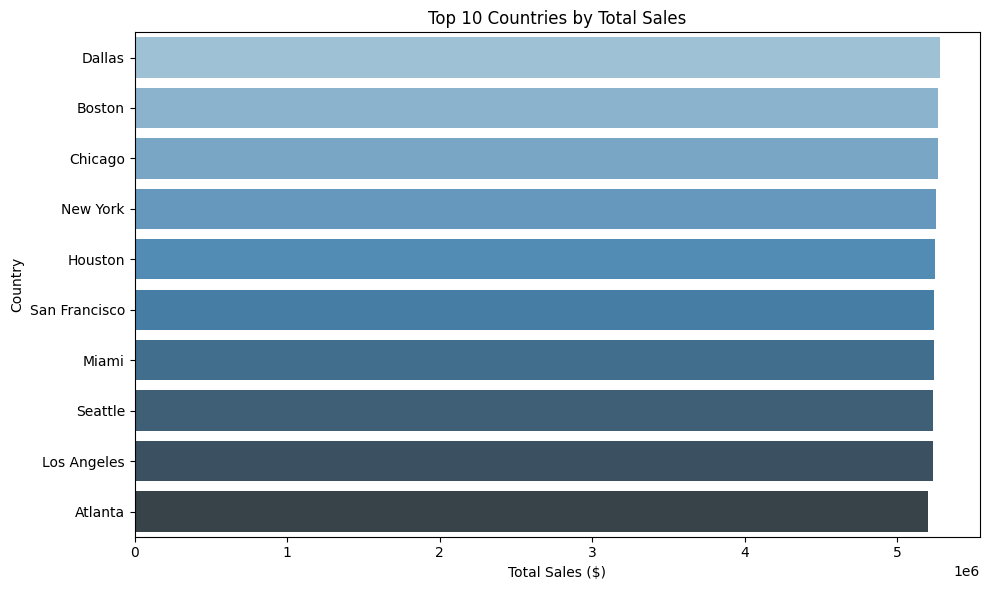

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27212\3534803983.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_total_sales', y=label_col, data=prod_pd, palette='Greens_d')


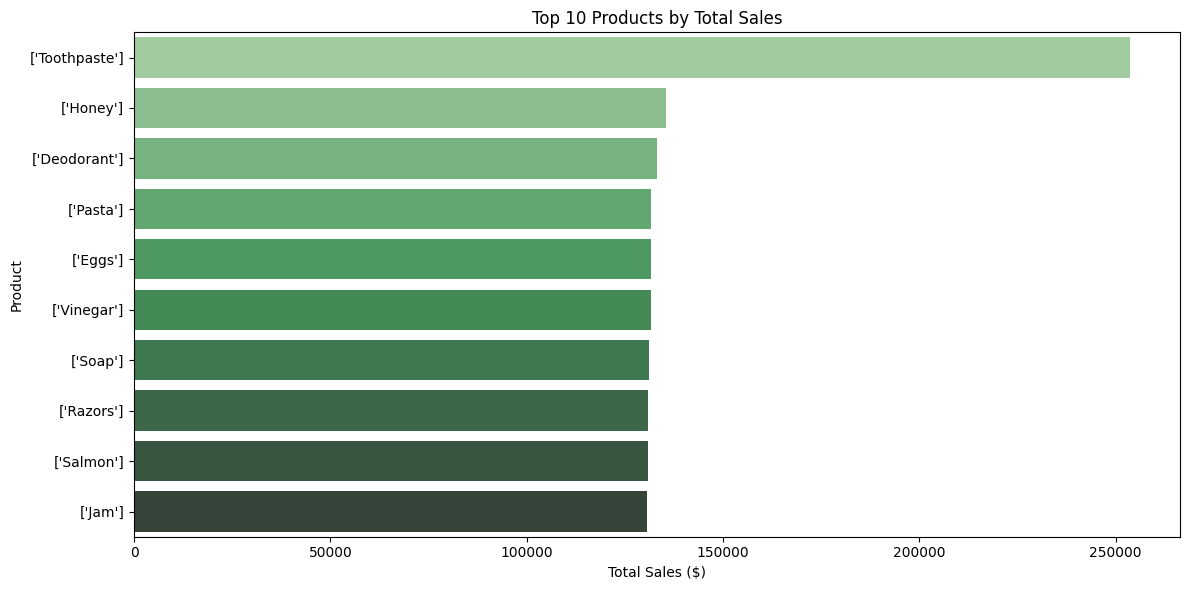

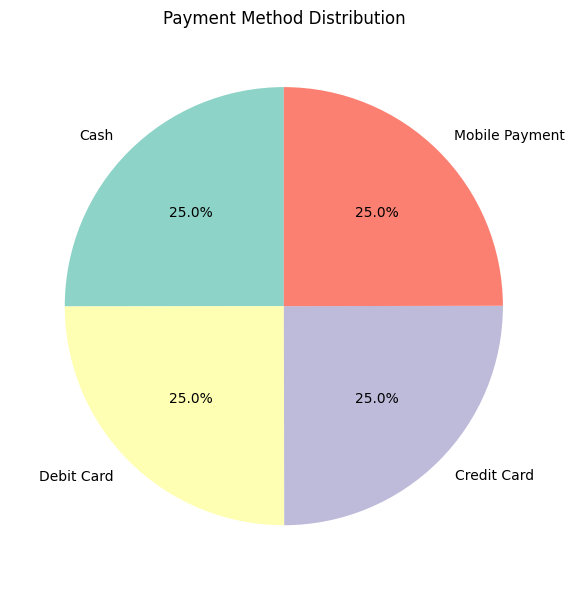

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27212\3534803983.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Season', y='Revenue', data=season_revenue, palette='coolwarm')


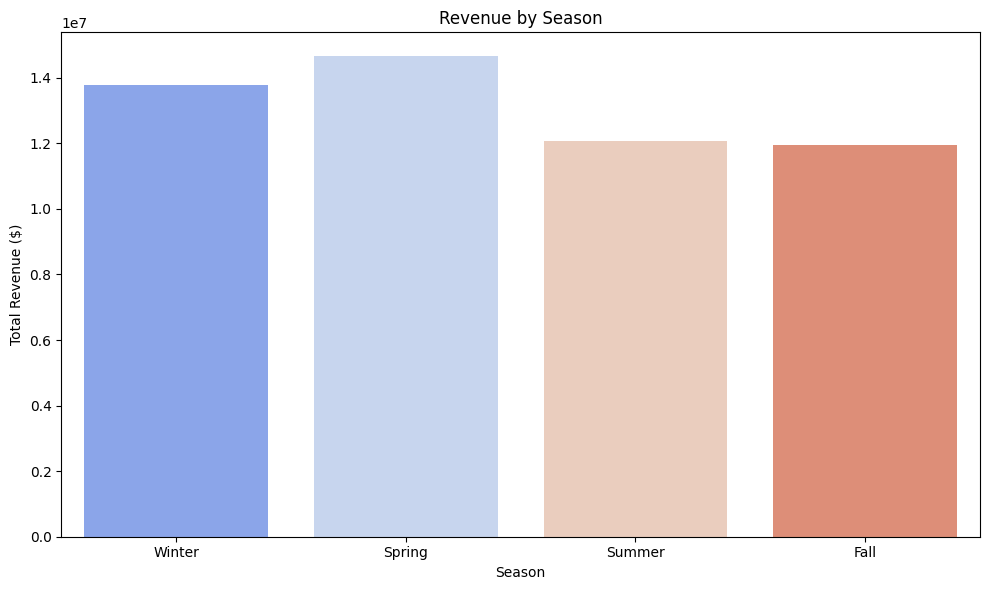

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot top countries if available
if country_sales is not None:
    country_pd = country_sales.head(10)
    x_col = country_pd.columns[0]
    plt.figure(figsize=(10,6))
    sns.barplot(x='country_total_sales', y=x_col, data=country_pd, palette='Blues_d')
    plt.title('Top 10 Countries by Total Sales')
    plt.xlabel('Total Sales ($)')
    plt.ylabel('Country')
    plt.tight_layout()
    plt.show()
else:
    print('No country sales to plot')

# Plot top products if available
if product_sales is not None:
    prod_pd = product_sales.head(10)
    # choose a label column (prefer description)
    label_col = None
    for c in prod_pd.columns:
        if c.lower() in ('description', 'product', 'product_id'):
            label_col = c
            break
    if label_col is None: label_col = prod_pd.columns[0]
    plt.figure(figsize=(12,6))
    sns.barplot(x='product_total_sales', y=label_col, data=prod_pd, palette='Greens_d')
    plt.title('Top 10 Products by Total Sales')
    plt.xlabel('Total Sales ($)')
    plt.ylabel('Product')
    plt.tight_layout()
    plt.show()
else:
    print('No product sales to plot')

# Payment Distribution
payment_col = find_col('payment_method', 'Payment_Method', 'PaymentType', 'Payment')

if payment_col is not None:
    payment_dist = clean_sales[payment_col].value_counts()
    
    plt.figure(figsize=(10, 6))
    colors = plt.cm.Set3(range(len(payment_dist)))
    plt.pie(payment_dist.values, labels=payment_dist.index, autopct='%1.1f%%', 
            startangle=90, colors=colors)
    plt.title('Payment Method Distribution')
    plt.tight_layout()
    plt.show()
else:
    print('Payment method column not found; cannot plot payment distribution')

# Seasonal Revenue
date_col = find_col('date', 'Date', 'Transaction_Date', 'InvoiceDate')

if date_col is not None:
    clean_sales['date'] = pd.to_datetime(clean_sales[date_col], errors='coerce')
    clean_sales['month'] = clean_sales['date'].dt.month
    
    # Map months to seasons
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]:
            return 'Spring'
        elif month in [6, 7, 8]:
            return 'Summer'
        else:  # 9, 10, 11
            return 'Fall'
    
    clean_sales['season'] = clean_sales['month'].apply(get_season)
    
    # Revenue by season
    season_revenue = clean_sales.groupby('season')['total_price'].sum().reset_index()
    season_revenue.columns = ['Season', 'Revenue']
    season_order = ['Winter', 'Spring', 'Summer', 'Fall']
    season_revenue['Season'] = pd.Categorical(season_revenue['Season'], 
                                               categories=season_order, ordered=True)
    season_revenue = season_revenue.sort_values('Season')
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Season', y='Revenue', data=season_revenue, palette='coolwarm')
    plt.title('Revenue by Season')
    plt.ylabel('Total Revenue ($)')
    plt.tight_layout()
    plt.show()
else:
    print('Date column not found; cannot compute seasonal revenue')

## Task 5: How Spark distributes processing
- Spark splits data into partitions distributed to executors and performs transformations lazily. Aggregations may trigger shuffles where partitions exchange data across the network. We reduce to small summary tables and then collect them to the driver for plotting.

In [61]:
import time
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import sum, desc

# ============ SETUP ============
DATA_PATH = "../data/Retail_Transactions_Dataset.csv"

print("=" * 60)
print("PANDAS vs PYSPARK BENCHMARK")
print("=" * 60)

# ============ PANDAS ============
print("\n PANDAS TEST")
print("-" * 60)

# Test 1: Load data
start = time.time()
df_pandas = pd.read_csv(DATA_PATH)
pandas_load_time = time.time() - start
print(f"1. Load CSV: {pandas_load_time:.4f}s")

# Test 2: Group by and sum
start = time.time()
top_cities_pandas = (
    df_pandas.groupby("City")["Total_Cost"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
pandas_groupby_time = time.time() - start
print(f"2. Group by + Sort: {pandas_groupby_time:.4f}s")

# Test 3: Multiple aggregations
start = time.time()
result_pandas = (
    clean_sales.agg({
        "Total_Cost": "sum",
        "Total_Items": "mean",
        "Transaction_ID": "count"
    })
)
pandas_agg_time = time.time() - start
print(f"3. Multiple aggregations: {pandas_agg_time:.4f}s")

pandas_total = pandas_load_time + pandas_groupby_time + pandas_agg_time
print(f"\n PANDAS TOTAL: {pandas_total:.4f}s")

# ============ PYSPARK ============
print("\n PYSPARK TEST")
print("-" * 60)

# Test 0: Create session + Load data
spark_start = time.time()
spark = SparkSession.builder.appName("Benchmark").master("local[*]").getOrCreate()
spark_init_time = time.time() - spark_start
print(f"0. Spark initialization: {spark_init_time:.4f}s")

start = time.time()
df_spark = spark.read.csv(DATA_PATH, header=True, inferSchema=True)
spark_load_time = time.time() - start
print(f"1. Load CSV: {spark_load_time:.4f}s")

# Test 2: Group by and sum
start = time.time()
top_cities_spark = (
    df_spark.groupBy("City")
    .agg(sum("Total_Cost").alias("total"))
    .orderBy(desc("total"))
    .limit(10)
    .collect()
)
spark_groupby_time = time.time() - start
print(f"2. Group by + Sort: {spark_groupby_time:.4f}s")

# Test 3: Multiple aggregations
start = time.time()
result_spark = (
    df_spark.groupBy("Store_Type")
    .agg({
        "Total_Cost": "sum",
        "Total_Items": "avg",
        "Transaction_ID": "count"
    })
    .collect()
)
spark_agg_time = time.time() - start
print(f"3. Multiple aggregations: {spark_agg_time:.4f}s")

spark.stop()

spark_total = spark_init_time + spark_load_time + spark_groupby_time + spark_agg_time
print(f"\n PYSPARK TOTAL: {spark_total:.4f}s")

# ============ COMPARISON ============
print("\n" + "=" * 60)
print(" RESULTS SUMMARY")
print("=" * 60)
print(f"\nPandas Total:   {pandas_total:.4f}s")
print(f"PySpark Total:  {spark_total:.4f}s")
# print(f"\nSpeedup: {spark_total / pandas_total:.1f}x faster with Pandas")
# print(f"Time saved: {spark_total - pandas_total:.4f}s ({((spark_total/pandas_total - 1) * 100):.1f}% slower with PySpark)")

PANDAS vs PYSPARK BENCHMARK

 PANDAS TEST
------------------------------------------------------------
1. Load CSV: 1.7565s
2. Group by + Sort: 0.0625s
3. Multiple aggregations: 0.0071s

 PANDAS TOTAL: 1.8261s

 PYSPARK TEST
------------------------------------------------------------
0. Spark initialization: 0.0722s
1. Load CSV: 0.3346s
2. Group by + Sort: 0.5123s
3. Multiple aggregations: 0.5968s

 PYSPARK TOTAL: 1.5158s

 RESULTS SUMMARY

Pandas Total:   1.8261s
PySpark Total:  1.5158s
